Vamos a usar el modelo del trabajo 2 entrenado con las 3 lineas celulares

In [2]:
import torch
import torch.nn as nn
import torch_geometric
import matplotlib.pyplot as plt
from scipy.stats import linregress
from torch.utils.data import TensorDataset, DataLoader
import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import numpy as np
from scipy.stats import pearsonr
import joblib

In [3]:
def samplewise_r2(y_true, y_pred):
   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   n_samples = y_true.shape[0]
   r2 = np.empty(n_samples, dtype=float)
   for i in range(n_samples):
      r2[i] = pearsonr(y_true[i], y_pred[i])[0] ** 2
   return r2

def gene_var_score(y_true, y_pred, eps=1e-12):

   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   var_true = np.var(y_true, axis=0)
   var_pred = np.var(y_pred, axis=0)
   ratio = (var_pred + eps) / (var_true + eps)
   score = np.exp(-np.abs(np.log(ratio)))
   return score

In [ ]:
# Cargamos los indices de la seleccion de genes (los mismos que en los otros colab)
final_gene_indices = joblib.load('recursos/final_gene_indices.pkl')
# Cargamos los valores de los escaladores para usar siempre los mismos
scaler_latente = joblib.load('recursos/scaler_latente_final.bin')

In [ ]:
# Autoencoder
class AutoencoderSC(nn.Module):
    def __init__(self, n_genes):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoencoderSC(n_genes= len(final_gene_indices) ).to(device)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
loss_fn_ae = nn.SmoothL1Loss()

# Le cargamos los pesos
ruta_guardado = 'recursos/autoencoder_definitivo_random_pesos.pth'
autoencoder.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación y lo congelamos
autoencoder.eval()
for param in autoencoder.parameters():
    param.requires_grad = False # Congela los pesos,

print("Autoencoder definitivo random cargado y listo")

Autoencoder definitivo random cargado y listo


In [ ]:
import math
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.act1 = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.act2 = nn.SiLU()

        # Capa para inyectar el contexto
        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # El contexto modifica el estado oculto de la célula
        h = self.linear1(x) + self.cond_proj(cond)
        h = self.act1(h)
        h = self.linear2(h)
        return h + x # Conexión residual (suma la entrada original)

class PerturbationDiffusion_v2(nn.Module):
    def __init__(self, latent_dim=128, diseased_dim=128, intervention_dim = len(final_gene_indices), hidden_dim=512, cond_dim=256, num_cell_lines=3+1): # +1 para la linea celular desconocida
      super().__init__()
      self.latent_dim = latent_dim
       # embedding de la t
      self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU()
        )
      # Procesador del estado basal 'diseased'
      self.diseased_mlp = nn.Sequential(
            nn.Linear(diseased_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Procesador de la intervención
      self.intervention_mlp = nn.Sequential(
            nn.Linear(intervention_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Embedding para la linea celular
      self.cell_line_emb = nn.Embedding(num_cell_lines, cond_dim)

      # Capa de entrada (recibe el latente ruidoso de la célula treated)
      self.init_lin = nn.Linear(latent_dim, hidden_dim)

      # Bloques residuales
      self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim)
        ])
      # Capa de salida (predice el ruido añadido)
      self.out_lin = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, t, diseased_state, intervention_vector, cell_line_idx):
        # Calculamos los 4 embeddings
        t_emb = self.time_mlp(t)
        dis_emb = self.diseased_mlp(diseased_state)
        int_emb = self.intervention_mlp(intervention_vector)
        line_emb = self.cell_line_emb(cell_line_idx)

        # Sumamos
        # "Nivel de ruido T" + "Estado Genético Previo" + "Gen Apagado" + 'Cell line
        context = t_emb + dis_emb + int_emb + line_emb

        # Pasamos el vector (con ruido) por la red de bloques residuales
        x = self.init_lin(x_t)

        for block in self.blocks:
            x = block(x, context) # Inyectamos el contexto biológico en cada capa

        # Predecimos el ruido para limpiar
        ruido_predicho = self.out_lin(x)
        return ruido_predicho

latent_dim = 128
diseased_dim = 128
intervention_dim =  len(final_gene_indices)
model = PerturbationDiffusion_v2(
    latent_dim=latent_dim,
    diseased_dim=diseased_dim,
    intervention_dim=intervention_dim
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Le cargamos los pesos del Drive
ruta_guardado =  'recursos/difusionv2_random_pesos.pth'
model.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación
model.eval()


# pesos ultima col del embeddimg de cell line sera el promedio de las otras 3
with torch.no_grad():
    weights = model.cell_line_emb.weight
    weights[3] = (weights[0]+ weights[1] + weights[2]) / 3

print("Modelo de difusion random cargado y listo")


Modelo de difusion random cargado y listo


In [11]:
@torch.no_grad()
def difusion(model, latentes_diseased, intervencion_real, cell_line_idx, t_start=0.95, num_steps=50, guidance_scale=3.0):
    model.eval()
    device = latentes_diseased.device
    num_celulas = latentes_diseased.shape[0]

    intervencion_nula = torch.zeros_like(intervencion_real, device=device)
    # Ruido inicial sobre el estado DISEASED
    t_inicial = torch.full((num_celulas, 1), t_start, device=device)
    epsilon = torch.randn_like(latentes_diseased)

    theta_inicial = t_inicial * (math.pi / 2)
    alpha_inicial = torch.cos(theta_inicial)
    sigma_inicial = torch.sin(theta_inicial)

    # Añadimos ruido a la célula enferma original
    z = alpha_inicial * latentes_diseased + sigma_inicial * epsilon

    # Pasos de tiempo
    tiempos = torch.linspace(t_start, 0.0, num_steps + 1, device=device)

    # Contrastive Guidance
    for i in range(num_steps):
        t_actual = tiempos[i] * torch.ones((num_celulas, 1), device=device)
        t_siguiente = tiempos[i+1] * torch.ones((num_celulas, 1), device=device)

        theta_actual = t_actual * (math.pi / 2)
        alpha_actual = torch.clamp(torch.cos(theta_actual), min=1e-4)
        sigma_actual = torch.sin(theta_actual)

        theta_siguiente = t_siguiente * (math.pi / 2)
        alpha_siguiente = torch.clamp(torch.cos(theta_siguiente), min=1e-4)
        sigma_siguiente = torch.sin(theta_siguiente)

        # Predicción ORIGEN
        pred_noise_origen = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_nula, cell_line_idx)

        # Predicción DESTINO
        pred_noise_destino = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_real, cell_line_idx)

        # APLICAMOS LA GUÍA
        pred_noise = pred_noise_origen + guidance_scale * (pred_noise_destino - pred_noise_origen)

        # Estimación z_0 y paso al siguiente t
        z_0_pred = (z - sigma_actual * pred_noise) / alpha_actual
        z = alpha_siguiente * z_0_pred + sigma_siguiente * pred_noise

    return z

In [ ]:
# Esta es la funcion a usar
def predicciones(data,final_gene_indices = final_gene_indices, guidance_scale = 2.0 ):
    for sample in data:
        sample['cell_line'] = torch.tensor([3], dtype=torch.long)

    # Hacemos las matrices para el Test data
    diseased_tensor_data = torch.stack([d.diseased for d in data])
    intervention_tensor_data = torch.stack([d.intervention for d in data])
    treated_tensor_data = torch.stack([d.treated for d in data])

    diseased_matrix_data = diseased_tensor_data[:, final_gene_indices].numpy()
    treated_matrix_data = treated_tensor_data[:, final_gene_indices].numpy()
    intervention_matrix_data = intervention_tensor_data[:, final_gene_indices].numpy()

    cell_test = torch.tensor([sample['cell_line'].item() for sample in data], dtype=torch.long).to(device)

    x_dis_test = torch.tensor(diseased_matrix_data, dtype=torch.float32).to(device)
    y_tre_test = torch.tensor(treated_matrix_data, dtype=torch.float32).to(device)
    int_test = torch.tensor(intervention_matrix_data, dtype=torch.float32).to(device)

    autoencoder.eval()
    # Bajamos CPU
    with torch.no_grad():
        z_dis_test = autoencoder.encoder(x_dis_test).cpu().numpy()
        z_tre_test = autoencoder.encoder(y_tre_test).cpu().numpy()

    # Escalar
    z_dis_test_scaled = scaler_latente.transform(z_dis_test)
    z_tre_test_scaled = scaler_latente.transform(z_tre_test)

    # Dataloader y tensores
    z_tre_t_test = torch.tensor(z_tre_test_scaled, dtype=torch.float32).to(device)
    z_dis_t_test = torch.tensor(z_dis_test_scaled, dtype=torch.float32).to(device)
    dataset_test_diff = TensorDataset(z_tre_t_test, z_dis_t_test, int_test, cell_test)
    loader_test_diff = DataLoader(dataset_test_diff, batch_size=128, shuffle=False)

    y_true_genes_sub = treated_matrix_data  # Datos reales originales

    # Ejecutamos la predicción guiada
    z_pred_scaled = difusion(model,
        z_dis_t_test,
        int_test,
        cell_test,
        guidance_scale= guidance_scale
    )

    # Desescalar y Decodificar
    z_pred_unscaled = scaler_latente.inverse_transform(z_pred_scaled.cpu().numpy())
    z_pred_torch = torch.tensor(z_pred_unscaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        y_pred_genes = autoencoder.decoder(z_pred_torch).cpu().numpy()

        # Metricas
        mse_linea = np.mean((y_true_genes_sub - y_pred_genes)**2)
        r2_samples = samplewise_r2(y_true_genes_sub, y_pred_genes)
        var_score = gene_var_score(y_true_genes_sub, y_pred_genes).mean()

    print(f"MSE de la linea nueva es: {mse_linea:.4f}")
    print(f"R² promedio de la linea nueva es: {r2_samples.mean():.4f}")
    print(f"Gene Variance Score de la linea nueva es : {var_score:.4f}")

    # Grafico
    std_real = np.std(y_true_genes_sub, axis=0)
    std_pred_diff = np.std(y_pred_genes, axis=0)

    plt.figure(figsize=(8, 8))

    # Dibujamos los puntos (cada punto es uno de tus miles de genes)
    plt.scatter(std_real, std_pred_diff, alpha=0.4, color='#1f77b4', edgecolors='white', s=30, label='Genes')

    slope, intercept, r_value, p_value_dif, std_err_diff = linregress(std_real, std_pred_diff)

    # Dibujamos la línea de Identidad (La perfección: si real=0.8, pred=0.8)
    max_val = max(np.max(std_real), np.max(std_pred_diff))
    plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2.5, label='Línea de Identidad (Ideal)')

    x_vals = np.array([0, max_val])
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, color='red', label='Ajuste diff')

    plt.title("Recuperación de la Varianza Génica con Modelo de Difusión", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Desviación Estándar Real (Células Treated)", fontsize=12)
    plt.ylabel("Desviación Estándar Predicha (Modelo Difusión)", fontsize=12)

    plt.xlim(0, max_val * 1.05)
    plt.ylim(0, max_val * 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', fontsize=11)

    plt.tight_layout()
    plt.show()
    return y_pred_genes


# Funcion lista

## Si la prediccion no sale muy bien, se puede modificar el guidance_scale. Como se ve mas abajo puede cambiar bastante.
Por defecto esta puesto en 2 pero puede no ser la mas optima 

In [ ]:
PC3 =  torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_PC3.pt', weights_only=False )

MSE de la linea nueva es: 0.0470
R² promedio de la linea nueva es: 0.8053
Gene Variance Score de la linea nueva es : 0.7458


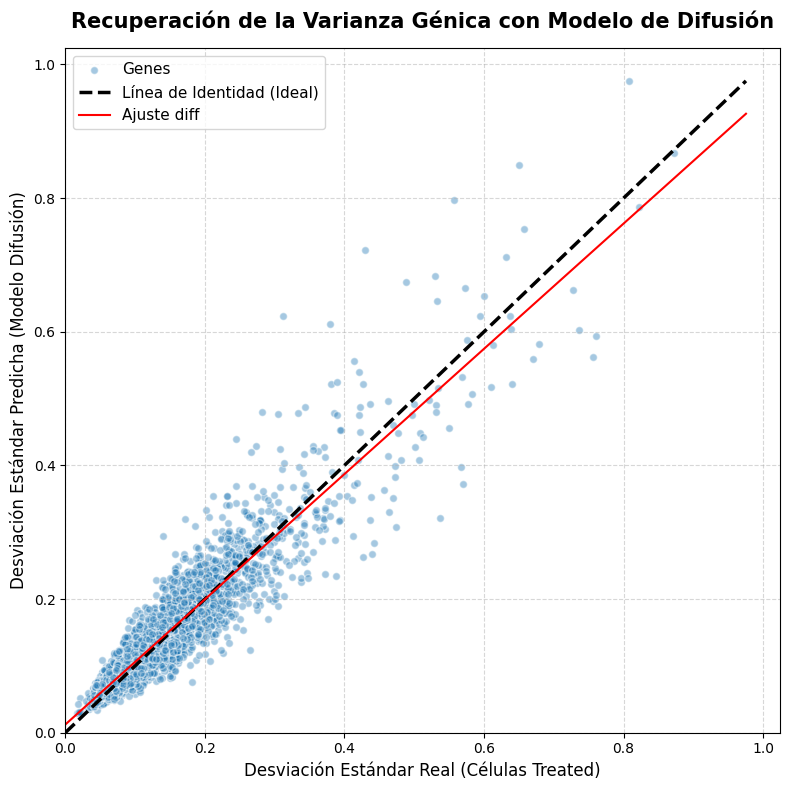

In [20]:
y_pred = predicciones(PC3,guidance_scale= 2.0)

MSE de la linea nueva es: 0.0859
R² promedio de la linea nueva es: 0.7241
Gene Variance Score de la linea nueva es : 0.3368


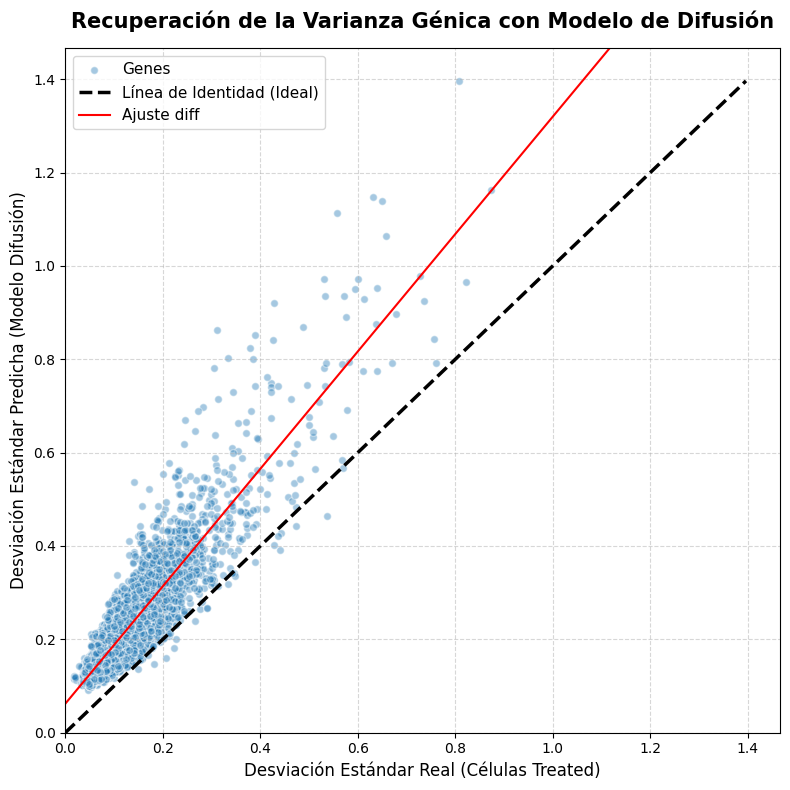

In [21]:
y_pred = predicciones(PC3,guidance_scale= 5.0)